# Using quantstats library

## Basic usage of quantstats

In [ ]:
## Install required python library 
!python3 -m pip install quantstats
# Install the C library via Homebrew (for macOS)
!brew install ta-lib
# Install the Python wrapper
!python3 -m pip install TA-Lib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [quantstats]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import quantstats as qs
returns = qs.utils.download_returns('AAPL')
benchmark = qs.utils.download_returns('SPY')
returns

Date
1980-12-12    0.000000
1980-12-15   -0.052171
1980-12-16   -0.073398
1980-12-17    0.024750
1980-12-18    0.028993
                ...   
2026-08-31   -0.008915
2026-09-01    0.026132
2026-09-02   -0.000523
2026-09-03    0.010001
2026-09-04   -0.025106
Name: Close, Length: 11525, dtype: float64

In [4]:
qs.stats.sharpe(returns)

np.float64(0.6271161956548411)

In [5]:
qs.stats.cagr(returns)

np.float64(0.1934960695616852)

In [8]:
qs.stats.max_drawdown(returns)

np.float64(-0.818014461371384)

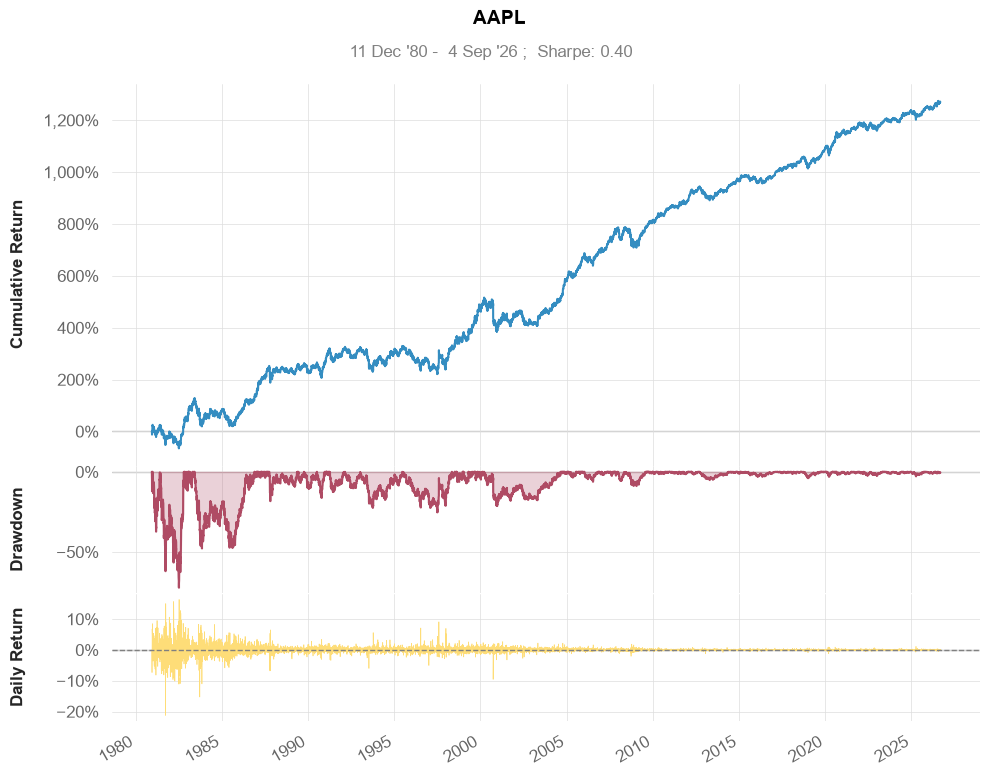

In [12]:
qs.plots.snapshot(returns, benchmark=benchmark, title='AAPL', mode='full')

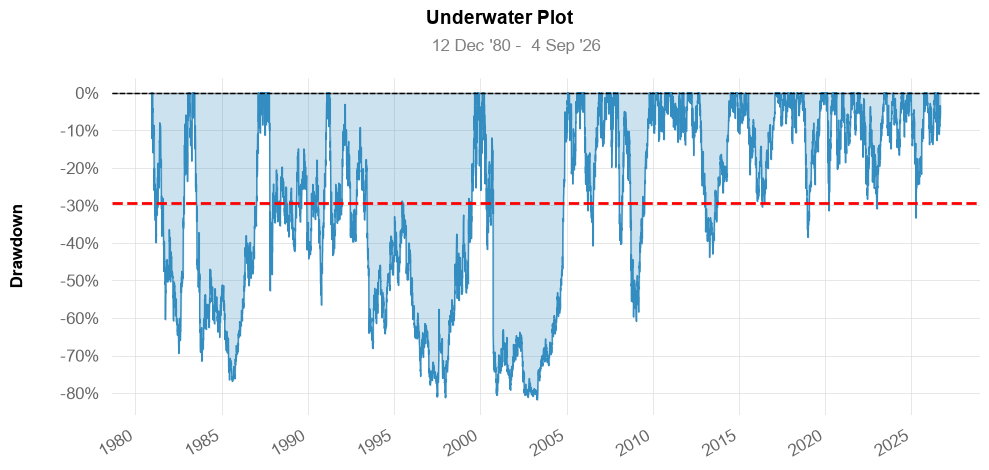

In [14]:
qs.plots.drawdown(returns)

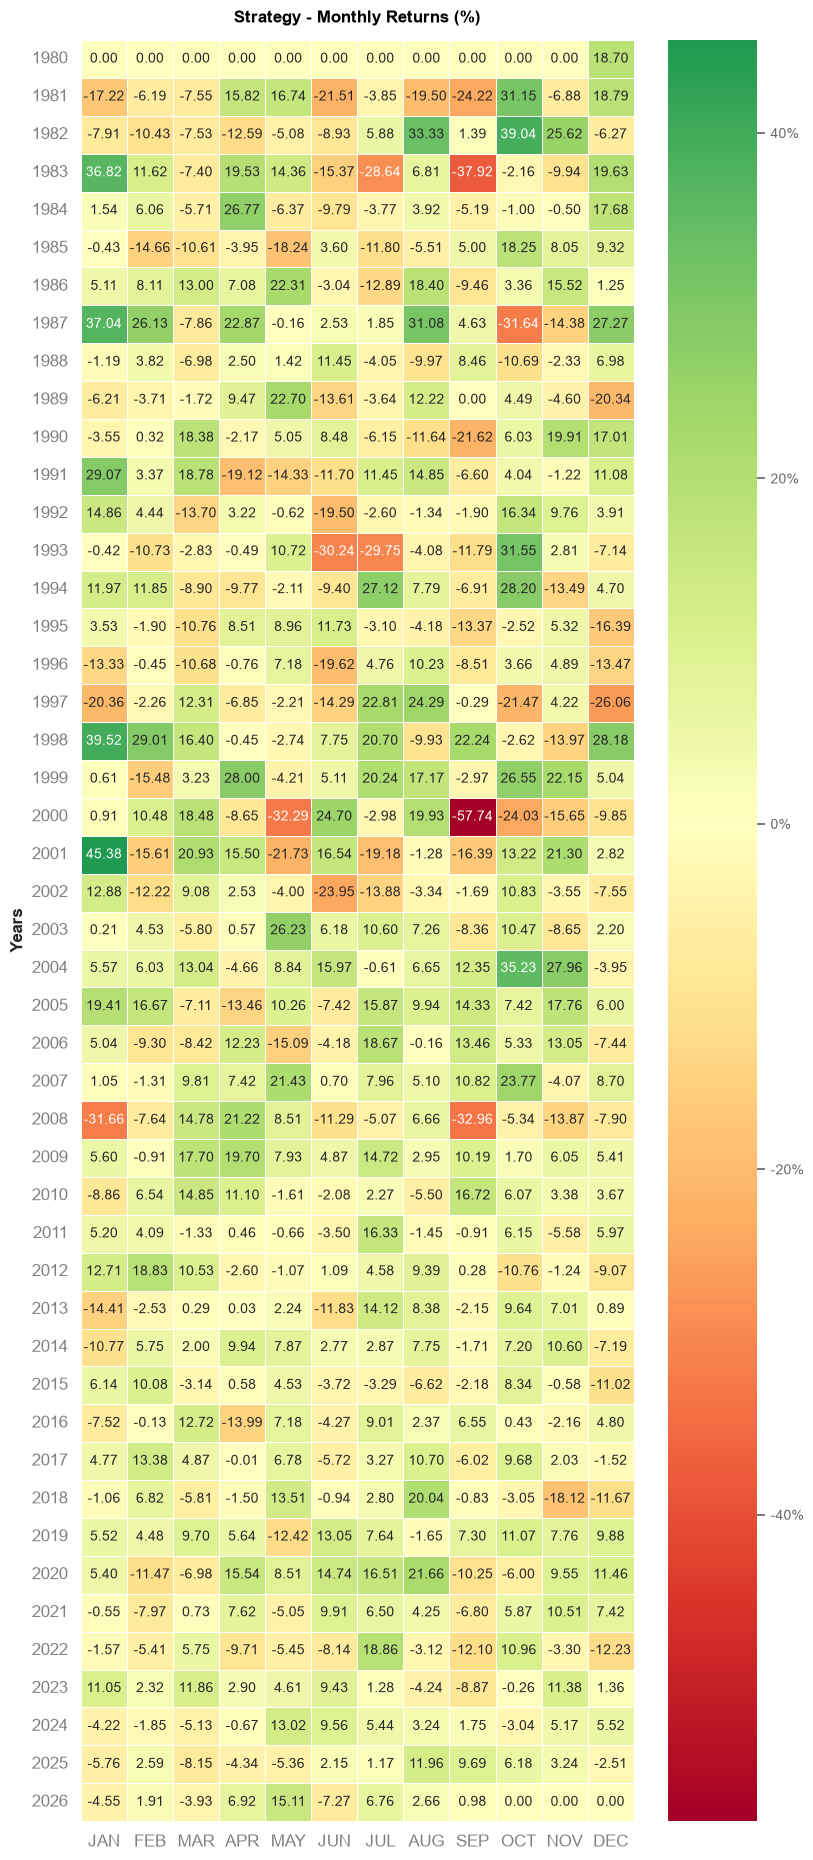

In [15]:
qs.plots.monthly_heatmap(returns)

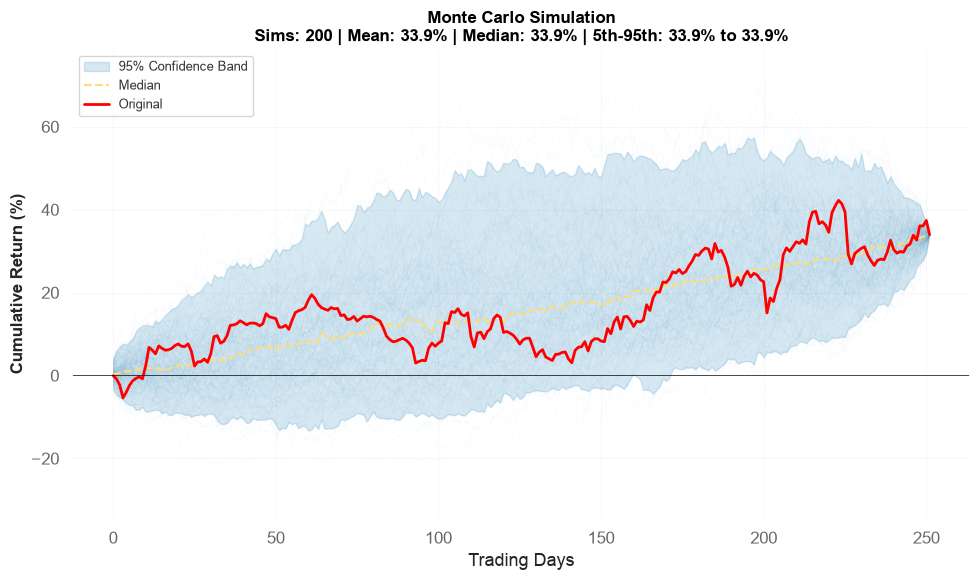

In [24]:
qs.plots.montecarlo(returns.tail(252), sims=200)

In [25]:
qs.stats.montecarlo(returns).stats

{'min': np.float64(3259.926832798145),
 'max': np.float64(3259.926832798232),
 'mean': np.float64(3259.926832798188),
 'median': np.float64(3259.926832798187),
 'std': np.float64(1.558027632765005e-11),
 'percentile_5': np.float64(3259.926832798163),
 'percentile_25': np.float64(3259.926832798177),
 'percentile_75': np.float64(3259.9268327981986),
 'percentile_95': np.float64(3259.9268327982145)}

In [28]:
qs.reports.html(returns, benchmark=benchmark, title="AAPL vs SPY", output='report.html')

## Portfolio analysis

In [32]:
import pandas as pd
portfolio_weights = {'AAPL':0.2, 'NVDA': 0.3, 'TSLA': 0.15, 'MSFT': 0.2, 'META': 0.15}

returns = pd.DataFrame({
    ticker: qs.utils.download_returns(ticker) for ticker in portfolio_weights
}).dropna()

portfolio = (returns * pd.Series(portfolio_weights)).sum(axis=1).rename('Portfolio')
sp500 = qs.utils.download_returns('SPY').rename('SPY500')
portfolio

Date
2012-05-18   -0.021751
2012-05-21    0.010254
2012-05-22   -0.007902
2012-05-23    0.013835
2012-05-24   -0.008820
                ...   
2026-08-31    0.007025
2026-09-01   -0.004994
2026-09-02    0.011933
2026-09-03    0.025401
2026-09-04   -0.013986
Name: Portfolio, Length: 3595, dtype: float64

In [33]:
qs.reports.html(portfolio, sp500, title='Portfolo vs S&P 500' ,output='portfolio-report.html')

## Use quantstats for backtest

In [39]:
## Install required python library 
!python3 -m pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.1 MB/s  0:00:00m 4.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [TA-Lib]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [41]:
import talib as ta
import yfinance as yf

price = yf.Ticker('AAPL').history(start='2010-01-01')['Close']
price.index = price.index.tz_localize(None)

macd, signal, hist = ta.MACD(price)
position = (macd > signal).shift().fillna(False).astype(int)
daily = price.pct_change().fillna(0)

strategy = (daily * position).rename('MACD')
buy_hold = daily.rename('Buy and Hold')

strategy = strategy.dropna()
buy_hold = buy_hold.reindex(strategy.index).fillna(0)

qs.reports.html(strategy, buy_hold, title='MACD vs BuyHold', output='macd.html')

